### **Image Segmentation**

In [25]:
import cv2 as cv
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import cv2

In [26]:
# Perform K-Means based image segmentation after Gaussian smoothing,
# cluster pixel intensities into K regions, reconstruct the segmented image,
# and report the pixel count for each segment.
def segment_image(image, K=5):
  image = cv.GaussianBlur(image, (11, 11), 0)
  pixels = image.reshape(-1, 1)
  kmeans = KMeans(n_clusters=K, random_state=42)
  labels = kmeans.fit_predict(pixels)
  segmented_image = kmeans.cluster_centers_.astype(np.float32)[labels].reshape(image.shape)
  for i in range(K):
    print("Number of Pixesl for part " + str(i) + ":", np.sum(labels==i))

  return segmented_image

In [27]:
# Segment Hue channel using K-Means (K=3) with Gaussian smoothing.
k = 3
image = cv.imread("img/flower_1.jpg")
o_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
HSV = cv.cvtColor(image, cv.COLOR_BGR2HSV)
Hue = HSV[:,:,0]
segmented = segment_image(Hue, k)

Number of Pixesl for part 0: 3028400
Number of Pixesl for part 1: 908501
Number of Pixesl for part 2: 875799


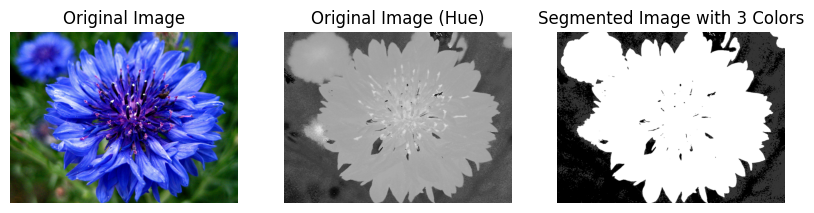

In [28]:
# Display original image, original Hue channel, and segmented image with K colors.
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(o_image, cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"Segmented Image with {k} Colors")
plt.imshow(segmented, cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Original Image (Hue)")
plt.imshow(Hue, cmap="gray")
plt.axis('off')
plt.show()